In [1]:
import sys
sys.path.append("../src")

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from model import DyckTransformer
from data import generate_examples
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}

model = DyckTransformer(
    vocab_size=len(VOCAB), pad_idx=stoi["[PAD]"],
    num_edit_labels=6, d_model=128, n_heads=4,
    n_layers=2, max_len=80, dropout=0.1
)
model.load_state_dict(torch.load("../results/models/det_dyck_transformer.pt", map_location=device))
model.eval()

def tokens_to_ids(tokens, stoi):
    return torch.tensor([[stoi[t] for t in tokens]])

In [2]:
def get_depth_sequence(tokens):
    """
    For each token position, return the nesting depth AFTER processing that token.
    [CLS], [SEP], [PAD] get depth 0.
    """
    depths = []
    stack = []
    for tok in tokens:
        if tok in ("(", "["):
            stack.append(tok)
            depths.append(len(stack))
        elif tok in (")", "]"):
            if stack:
                stack.pop()
            depths.append(len(stack))
        else:
            depths.append(0)  # CLS, SEP, PAD
    return depths

def get_max_depth(tokens):
    return max(get_depth_sequence(tokens))

In [3]:
def get_hidden_states(model, input_ids):
    """
    Returns hidden states after each layer.
    List of length n_layers+1 (including embedding layer),
    each of shape (seq_len, d_model).
    """
    hidden_states = []

    with torch.no_grad():
        x = model.embed(input_ids)
        x = model.pos(x)
        hidden_states.append(x.squeeze(0).numpy())  # after embedding

        for layer in model.encoder.layers:
            x = layer(x)
            hidden_states.append(x.squeeze(0).numpy())  # after each layer

    return hidden_states  # list of (seq_len, d_model)

# Generate data
all_examples = generate_examples(2000, max_depth=4, corrupt_prob=0.5, task="detection")
correct = [(t, l) for t, l in all_examples if l == 1]
corrupted = [(t, l) for t, l in all_examples if l == 0]
print(f"Correct: {len(correct)}, Corrupted: {len(corrupted)}")

Correct: 1009, Corrupted: 991


In [4]:
# Extract CLS representation (position 0) from final layer
X_cls, y_depth = [], []

for tokens, label in correct[:500]:
    ids = tokens_to_ids(tokens, stoi)
    hidden = get_hidden_states(model, ids)
    cls_repr = hidden[-1][0]  # final layer, position 0 = [CLS]
    max_depth = get_max_depth(tokens)
    X_cls.append(cls_repr)
    y_depth.append(max_depth)

X_cls = np.array(X_cls)
y_depth = np.array(y_depth)

# Split train/test
split = int(0.8 * len(X_cls))
X_train, X_test = X_cls[:split], X_cls[split:]
y_train, y_test = y_depth[:split], y_depth[split:]

# Linear regression → R²
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Global depth probe R² = {r2:.4f}")

# k-class classifier → accuracy
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Global depth classifier accuracy = {acc:.4f}")
print(f"Depth distribution: {dict(zip(*np.unique(y_depth, return_counts=True)))}")

Global depth probe R² = 0.8881
Global depth classifier accuracy = 0.8300
Depth distribution: {np.int64(1): np.int64(22), np.int64(2): np.int64(32), np.int64(3): np.int64(21), np.int64(4): np.int64(425)}


Layer 0 R² = 0.5138
Layer 1 R² = 0.5789
Layer 2 R² = 0.5781


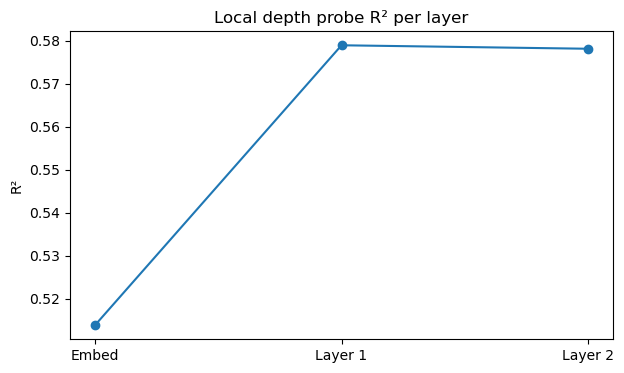

In [5]:
# For each layer, train a probe to predict depth at each token position
n_layers_total = len(model.encoder.layers) + 1  # +1 for embedding layer
r2_per_layer = []

for layer_idx in range(n_layers_total):
    X_local, y_local = [], []
    
    for tokens, label in correct[:500]:
        ids = tokens_to_ids(tokens, stoi)
        hidden = get_hidden_states(model, ids)
        depths = get_depth_sequence(tokens)
        real_len = sum(1 for t in tokens if t != "[PAD]")
        
        for pos in range(1, real_len - 1):  # skip [CLS] and [SEP]
            X_local.append(hidden[layer_idx][pos])
            y_local.append(depths[pos])
    
    X_local = np.array(X_local)
    y_local = np.array(y_local)
    
    split = int(0.8 * len(X_local))
    reg = LinearRegression().fit(X_local[:split], y_local[:split])
    r2 = r2_score(y_local[split:], reg.predict(X_local[split:]))
    r2_per_layer.append(r2)
    print(f"Layer {layer_idx} R² = {r2:.4f}")

# Plot
plt.figure(figsize=(7, 4))
plt.plot(range(n_layers_total), r2_per_layer, marker='o')
plt.xticks(range(n_layers_total), ["Embed", "Layer 1", "Layer 2"])
plt.ylabel("R²")
plt.title("Local depth probe R² per layer")
plt.savefig("../results/figures/probing_r2_per_layer.png", dpi=150)
plt.show()

In [6]:
from data import generate_examples_with_error_type

# Find error position from edit labels
def find_error_pos(edit_labels):
    for i, l in enumerate(edit_labels):
        if l != "OK":
            return i
    return None

# For each corrupted sequence, compare probe predictions before vs after error
from data import generate_examples
corrupted_full = generate_examples(500, max_depth=4, corrupt_prob=1.0, task="both")

Mean absolute error BEFORE corruption: 1.4408
Mean absolute error AFTER corruption:  1.4689


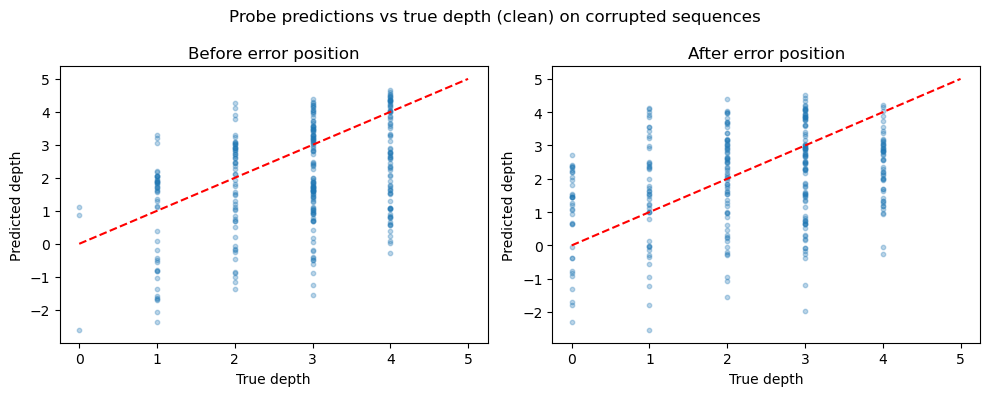

In [7]:
# Train probe on correct data (layer 2) - same as before
X_probe, y_probe = [], []
for tokens, label in correct[:400]:
    ids = tokens_to_ids(tokens, stoi)
    hidden = get_hidden_states(model, ids)
    depths = get_depth_sequence(tokens)
    real_len = sum(1 for t in tokens if t != "[PAD]")
    for pos in range(1, real_len - 1):
        X_probe.append(hidden[2][pos])
        y_probe.append(depths[pos])

probe = LinearRegression().fit(np.array(X_probe), np.array(y_probe))

# For Q15: generate clean sequences, compute clean depths,
# then apply each error type and compare probe predictions
from data import generate_clean, E1_missing_closer, E2_spurious_opener, E3_type_mismatch, E4_premature_close

parenthesis = {"(": ")", "[": "]"}
error_fns = [E1_missing_closer, E2_spurious_opener, E3_type_mismatch, E4_premature_close]

errors_before, errors_after = [], []
pred_depth_before, pred_depth_after = [], []
true_depth_before, true_depth_after = [], []

for _ in range(500):
    clean = generate_clean(parenthesis, min_len=4, max_len=38, max_depth=4)
    fn = random.choice(error_fns)
    corrupted_seq, edit_info = fn(clean.copy(), parenthesis)
    if edit_info is None:
        continue

    # Shift for [CLS]
    if edit_info[0] == "DELETE":
        edit_info = ("DELETE", edit_info[1] + 1)
    elif edit_info[0] == "REPLACE":
        edit_info = ("REPLACE", edit_info[1] + 1, edit_info[2])
    elif edit_info[0] == "INSERT":
        edit_info = ("INSERT", edit_info[1] + 1, edit_info[2])

    # Build corrupted token sequence
    corrupted_tokens = ["[CLS]"] + corrupted_seq + ["[SEP]"]
    while len(corrupted_tokens) < 80:
        corrupted_tokens.append("[PAD]")
    corrupted_tokens = corrupted_tokens[:80]

    # Use CLEAN sequence for ground truth depths
    clean_tokens = ["[CLS]"] + clean + ["[SEP]"]
    while len(clean_tokens) < 80:
        clean_tokens.append("[PAD]")
    clean_depths = get_depth_sequence(clean_tokens)

    err_pos = edit_info[1]
    real_len = sum(1 for t in corrupted_tokens if t != "[PAD]")

    ids = tokens_to_ids(corrupted_tokens, stoi)
    hidden = get_hidden_states(model, ids)

    for pos in range(1, min(real_len - 1, len(clean_depths))):
        pred = probe.predict(hidden[2][pos].reshape(1, -1))[0]
        true = clean_depths[pos]
        err = abs(pred - true)
        if pos < err_pos:
            errors_before.append(err)
            pred_depth_before.append(pred)
            true_depth_before.append(true)
        else:
            errors_after.append(err)
            pred_depth_after.append(pred)
            true_depth_after.append(true)

print(f"Mean absolute error BEFORE corruption: {np.mean(errors_before):.4f}")
print(f"Mean absolute error AFTER corruption:  {np.mean(errors_after):.4f}")

# Plot predicted vs true depth before and after error
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(true_depth_before[:300], pred_depth_before[:300], alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel("True depth"); plt.ylabel("Predicted depth")
plt.title("Before error position")

plt.subplot(1, 2, 2)
plt.scatter(true_depth_after[:300], pred_depth_after[:300], alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel("True depth"); plt.ylabel("Predicted depth")
plt.title("After error position")

plt.suptitle("Probe predictions vs true depth (clean) on corrupted sequences")
plt.tight_layout()
plt.savefig("../results/figures/probing_before_after_error.png", dpi=150)
plt.show()

In [8]:
# Localisation experiment: can we find the error position from probe predictions alone?
from data import generate_clean, E1_missing_closer, E2_spurious_opener, E3_type_mismatch, E4_premature_close

correct_distances = []   # distance between predicted error pos and true error pos

for _ in range(200):
    clean = generate_clean(parenthesis, min_len=6, max_len=38, max_depth=4)
    fn = random.choice(error_fns)
    corrupted_seq, edit_info = fn(clean.copy(), parenthesis)
    if edit_info is None:
        continue

    if edit_info[0] == "DELETE":
        edit_info = ("DELETE", edit_info[1] + 1)
    elif edit_info[0] == "REPLACE":
        edit_info = ("REPLACE", edit_info[1] + 1, edit_info[2])
    elif edit_info[0] == "INSERT":
        edit_info = ("INSERT", edit_info[1] + 1, edit_info[2])

    corrupted_tokens = ["[CLS]"] + corrupted_seq + ["[SEP]"]
    while len(corrupted_tokens) < 80:
        corrupted_tokens.append("[PAD]")
    corrupted_tokens = corrupted_tokens[:80]

    clean_tokens = ["[CLS]"] + clean + ["[SEP]"]
    while len(clean_tokens) < 80:
        clean_tokens.append("[PAD]")
    clean_depths = get_depth_sequence(clean_tokens)

    real_len = sum(1 for t in corrupted_tokens if t != "[PAD]")
    ids = tokens_to_ids(corrupted_tokens, stoi)
    hidden = get_hidden_states(model, ids)

    # Get probe predictions for each position
    preds = [probe.predict(hidden[2][pos].reshape(1, -1))[0] 
             for pos in range(1, real_len - 1)]
    trues = clean_depths[1:real_len - 1]

    # Localisation: find position of maximum absolute deviation
    deviations = [abs(p - t) for p, t in zip(preds, trues)]
    predicted_err_pos = int(np.argmax(deviations)) + 1  # +1 for [CLS] offset
    true_err_pos = edit_info[1]

    correct_distances.append(abs(predicted_err_pos - true_err_pos))

print(f"Mean distance from true error: {np.mean(correct_distances):.2f} tokens")
print(f"Exact localisation (distance=0): {sum(d==0 for d in correct_distances)/len(correct_distances)*100:.1f}%")
print(f"Within 2 tokens: {sum(d<=2 for d in correct_distances)/len(correct_distances)*100:.1f}%")
print(f"Within 5 tokens: {sum(d<=5 for d in correct_distances)/len(correct_distances)*100:.1f}%")

Mean distance from true error: 6.87 tokens
Exact localisation (distance=0): 12.5%
Within 2 tokens: 26.5%
Within 5 tokens: 51.5%


In [9]:
# Check if classifier is just predicting the majority class
from collections import Counter
print("Predicted distribution:", Counter(clf.predict(X_test)))

Predicted distribution: Counter({np.int64(4): 100})


In [10]:
from data import generate_clean
import random

parenthesis = {"(": ")", "[": "]"}

def generate_balanced_examples(n_per_depth=200, depths=[1,2,3,4]):
    examples = []
    for d in depths:
        count = 0
        attempts = 0
        while count < n_per_depth and attempts < 10000:
            attempts += 1
            # Generate with exact max_depth = d by setting both min and max depth
            tokens = generate_clean(parenthesis, min_len=2*d, max_len=40, max_depth=d)
            actual_depth = max(get_depth_sequence(tokens))
            if actual_depth == d:  # only keep if it actually reaches depth d
                tokens = ["[CLS]"] + tokens + ["[SEP]"]
                while len(tokens) < 80:
                    tokens.append("[PAD]")
                tokens = tokens[:80]
                examples.append((tokens, d))
                count += 1
        print(f"Depth {d}: generated {count} examples")
    return examples

balanced_data = generate_balanced_examples(n_per_depth=200, depths=[1,2,3,4,5,6,7])

# Extract CLS representations
X_bal, y_bal = [], []
for tokens, depth in balanced_data:
    ids = tokens_to_ids(tokens, stoi)
    hidden = get_hidden_states(model, ids)
    cls_repr = hidden[-1][0]
    X_bal.append(cls_repr)
    y_bal.append(depth)

X_bal = np.array(X_bal)
y_bal = np.array(y_bal)

indices = np.random.permutation(len(X_bal))
X_bal = X_bal[indices]
y_bal = y_bal[indices]

split = int(0.8 * len(X_bal))
X_train_b, X_test_b = X_bal[:split], X_bal[split:]
y_train_b, y_test_b = y_bal[:split], y_bal[split:]

reg_b = LinearRegression().fit(X_train_b, y_train_b)
r2_b = r2_score(y_test_b, reg_b.predict(X_test_b))

clf_b = LogisticRegression(max_iter=1000).fit(X_train_b, y_train_b)
acc_b = accuracy_score(y_test_b, clf_b.predict(X_test_b))

print(f"Balanced R² = {r2_b:.4f}")
print(f"Balanced classifier accuracy = {acc_b:.4f}")
print(f"Predicted distribution: {Counter(clf_b.predict(X_test_b))}")

Depth 1: generated 200 examples
Depth 2: generated 200 examples
Depth 3: generated 200 examples
Depth 4: generated 200 examples
Depth 5: generated 200 examples
Depth 6: generated 200 examples
Depth 7: generated 200 examples
Balanced R² = 0.9359
Balanced classifier accuracy = 0.3643
Predicted distribution: Counter({np.int64(1): 85, np.int64(7): 68, np.int64(4): 57, np.int64(6): 41, np.int64(2): 22, np.int64(3): 7})


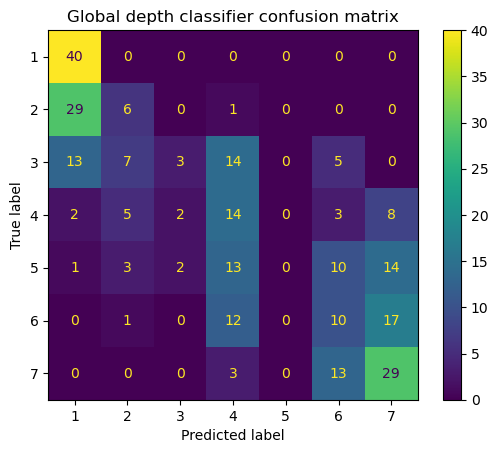

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_b, clf_b.predict(X_test_b), labels=[1,2,3,4,5,6,7])
disp = ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5,6,7])
disp.plot()
plt.title("Global depth classifier confusion matrix")
plt.savefig("../results/figures/probing_confusion_matrix.png", dpi=150)
plt.show()

Layer 0 | global R²=-0.0000 | acc=0.1286
Layer 1 | global R²=0.7948 | acc=0.4679
Layer 2 | global R²=0.9265 | acc=0.3321


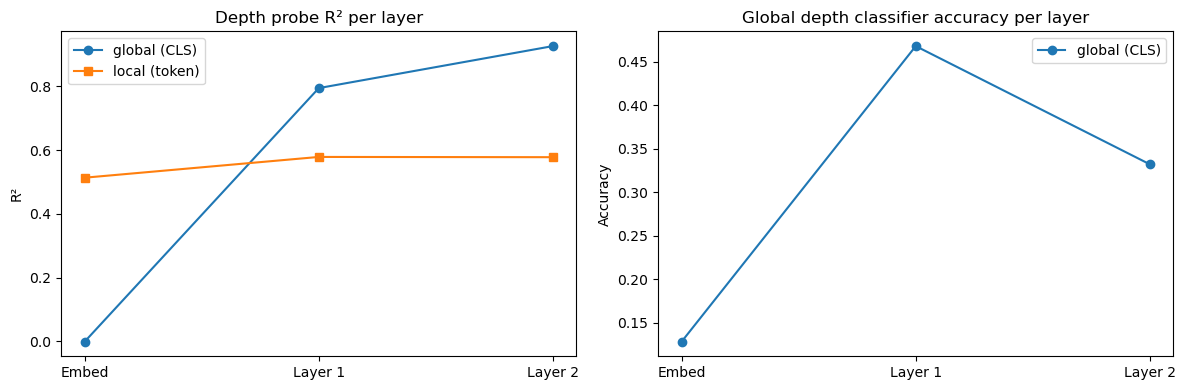

In [12]:
# Global depth probe per layer (CLS representation at each layer)
r2_global_per_layer = []
acc_global_per_layer = []

for layer_idx in range(n_layers_total):
    X_cls_layer, y_cls_layer = [], []
    
    for tokens, depth in balanced_data:
        ids = tokens_to_ids(tokens, stoi)
        hidden = get_hidden_states(model, ids)
        cls_repr = hidden[layer_idx][0]  # position 0 = [CLS]
        X_cls_layer.append(cls_repr)
        y_cls_layer.append(depth)
    
    X_cls_layer = np.array(X_cls_layer)
    y_cls_layer = np.array(y_cls_layer)
    
    # shuffle
    idx = np.random.permutation(len(X_cls_layer))
    X_cls_layer, y_cls_layer = X_cls_layer[idx], y_cls_layer[idx]
    
    split = int(0.8 * len(X_cls_layer))
    X_tr, X_te = X_cls_layer[:split], X_cls_layer[split:]
    y_tr, y_te = y_cls_layer[:split], y_cls_layer[split:]
    
    reg = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, reg.predict(X_te))
    r2_global_per_layer.append(r2)
    
    clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    acc_global_per_layer.append(acc)
    
    print(f"Layer {layer_idx} | global R²={r2:.4f} | acc={acc:.4f}")

# Plot both global and local on same figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
layer_names = ["Embed", "Layer 1", "Layer 2"]

ax1.plot(range(n_layers_total), r2_global_per_layer, marker='o', label="global (CLS)")
ax1.plot(range(n_layers_total), r2_per_layer, marker='s', label="local (token)")
ax1.set_xticks(range(n_layers_total))
ax1.set_xticklabels(layer_names)
ax1.set_ylabel("R²")
ax1.set_title("Depth probe R² per layer")
ax1.legend()

ax2.plot(range(n_layers_total), acc_global_per_layer, marker='o', label="global (CLS)")
ax2.set_xticks(range(n_layers_total))
ax2.set_xticklabels(layer_names)
ax2.set_ylabel("Accuracy")
ax2.set_title("Global depth classifier accuracy per layer")
ax2.legend()

plt.tight_layout()
plt.savefig("../results/figures/probing_per_layer.png", dpi=150)
plt.show()